In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

Reading dataset file.

In [23]:
houses = pd.read_csv('houses.csv', sep=None, engine='python');
houses.name = "Houses"

Printing number of records and attributes.

print(f"Number of records (rows): {houses.shape[0]}")
print(f"Number of attributes (columns): {houses.shape[1]}")

Attributes:
median_house_value – median value of houses in the area.
median_income – median income of households in the area.
housing_median_age – median age of houses in the area.
total_rooms – total number of rooms in all houses within the area.
total_bedrooms – total number of bedrooms in all houses within the area.
population – total number of people living in the area.
households – total number of households.
latitude – north–south geographical coordinate of the area.
longitude – east–west geographical coordinate of the area.

In [24]:
print(f"Attributs: {houses.columns.tolist()}")

Attributs: ['median_house_value', 'median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'latitude', 'longitude']


Data example:

In [25]:
houses.head(5)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3,41.0,880.0,129.0,322.0,126.0,37.9,-122.2
1,358500.0,8.3,21.0,7099.0,1106.0,2401.0,1138.0,37.9,-122.2
2,352100.0,7.3,52.0,1467.0,190.0,496.0,177.0,37.9,-122.2
3,341300.0,5.6,52.0,1274.0,235.0,558.0,219.0,37.9,-122.2
4,342200.0,3.8,52.0,1627.0,280.0,565.0,259.0,37.9,-122.2


Dataset has 0 duplicated records. That's great.

In [26]:
houses.duplicated().sum()

np.int64(0)

Dataset has 0 missing values. That's also great.

In [27]:
houses.isna().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

Cleaning outliers.

In [28]:
houses_cleaned = houses.copy()

for atr in houses_cleaned.columns:
    Q1 = houses_cleaned[atr].quantile(0.25)
    Q3 = houses_cleaned[atr].quantile(0.75)
    IQR = Q3 - Q1
    houses_cleaned = houses_cleaned[(houses_cleaned[atr] >= Q1 - 1.5 * IQR) & (houses_cleaned[atr] <= Q3 + 1.5 * IQR)]

print(f"Cleaned {houses.shape[0] - houses_cleaned.shape[0]} rows.")

Cleaned 3717 rows.


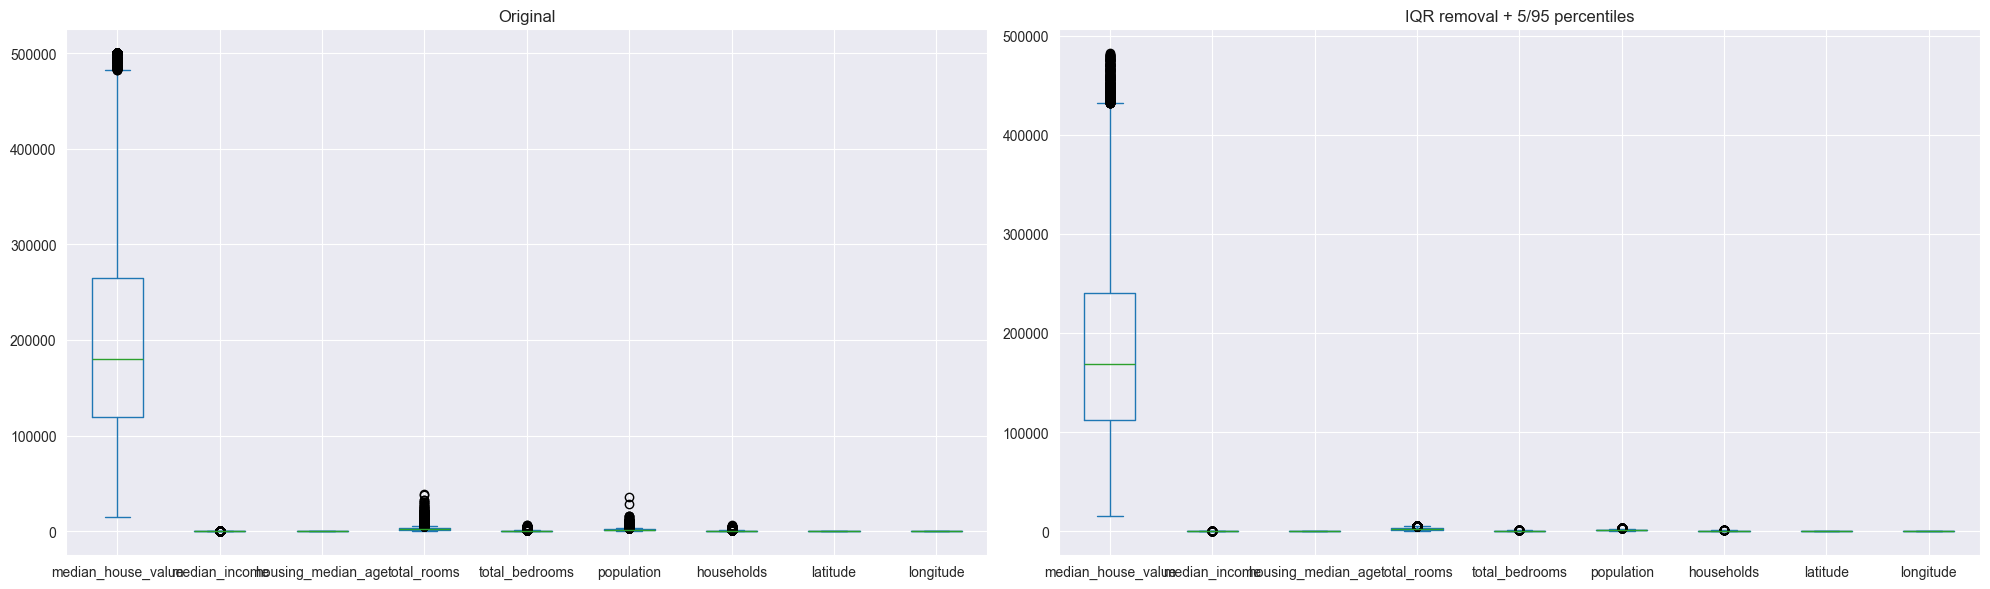

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
houses.plot.box(ax=axes[0], title="Original")
houses_cleaned.plot.box(ax=axes[1], title="IQR removal + 5/95 percentiles")
plt.tight_layout()
plt.show()

Printing Mean, median, min, max, std values of attributes after cleaning.

In [30]:
pd.options.display.float_format = "{:.1f}".format
houses_cleaned.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0
mean,185595.5,3.6,29.7,2075.4,428.7,1153.6,401.1,35.7,-119.6
std,93016.0,1.4,12.2,1026.1,202.1,553.7,187.4,2.2,2.0
min,14999.0,0.5,1.0,2.0,2.0,3.0,2.0,32.5,-124.3
25%,112500.0,2.5,20.0,1348.0,282.0,755.0,268.0,33.9,-121.8
50%,168800.0,3.4,30.0,1934.0,403.0,1088.0,380.0,34.4,-118.7
75%,240200.0,4.5,38.0,2692.0,557.0,1509.0,522.0,37.8,-118.0
max,482200.0,7.6,52.0,5600.0,1056.0,2762.0,916.0,42.0,-114.5


Attributes distribution: The difference interval for all attributes look valid.

array([[<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>]], dtype=object)

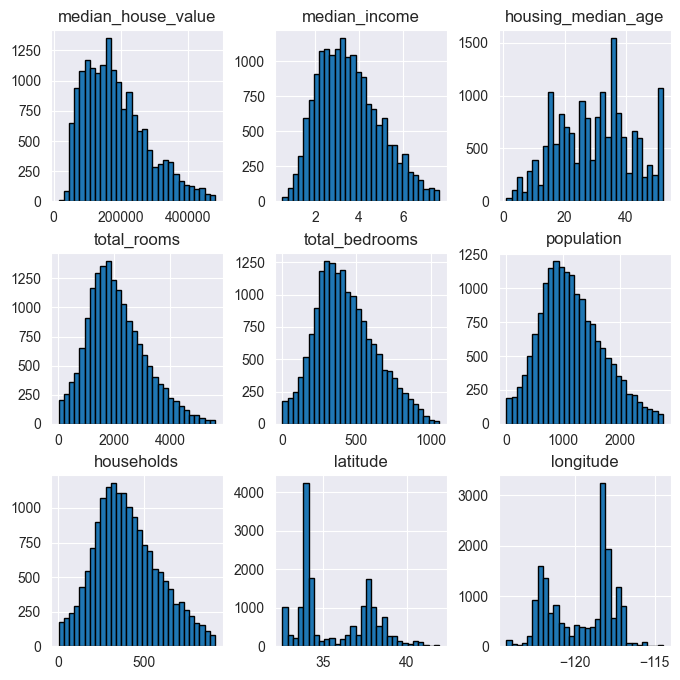

In [31]:
houses_cleaned.hist(figsize=(8, 8), bins=30, edgecolor='black')

None of the features have a strictly normal distribution. 'median_house_value', 'median_income', 'total_rooms', 'total_bedrooms', 'population', and 'households' have right-skewed distributions (skew > 0). 'housing_median_age' has a distribution similar to uniform. 'latitude' and 'longitude' are multi-peaked features, truncated by geography, clearly not normal.

In [32]:
houses_cleaned.skew()

median_house_value    0.8
median_income         0.5
housing_median_age   -0.0
total_rooms           0.6
total_bedrooms        0.5
population            0.5
households            0.4
latitude              0.4
longitude            -0.3
dtype: float64

Preliminary correlation analysis:
The main correlation that can be worked with is the correlation between attributes 'median_house_value' and 'median_income'. The remaining strong correlations are of no use because it is quite logical why they are so interrelated. If the value of 'total_bedrooms' increases, it is logical that the value of 'total_rooms' will also increase. The values of 'population' and 'households' will also increase because the more rooms there are, the more people can live in them, and more households will need to be built for these rooms.

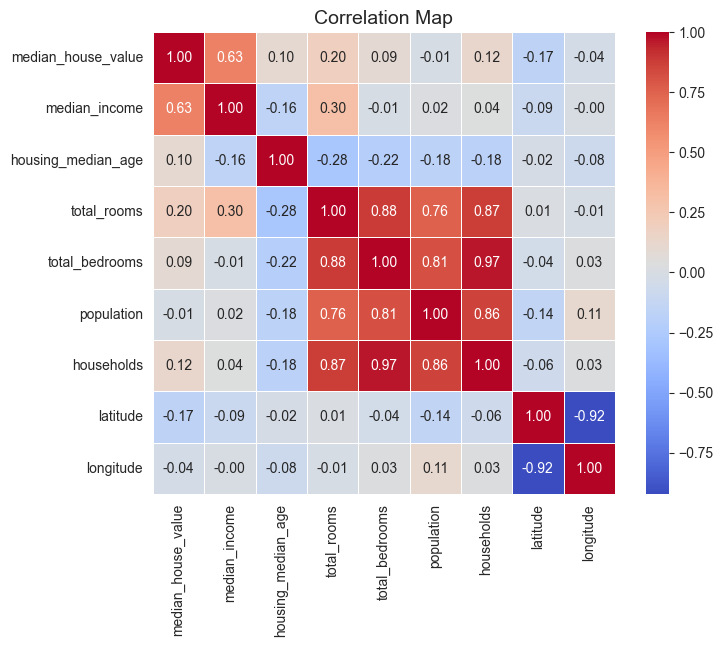

In [33]:
# Computing the correlation matrix
corr = houses_cleaned.corr(numeric_only=True)

# Plotting the map
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Map", fontsize=14)
plt.show()

Plotting graph of the relationship between 'median_house_value' and 'median_income'.

<Axes: xlabel='median_house_value', ylabel='median_income'>

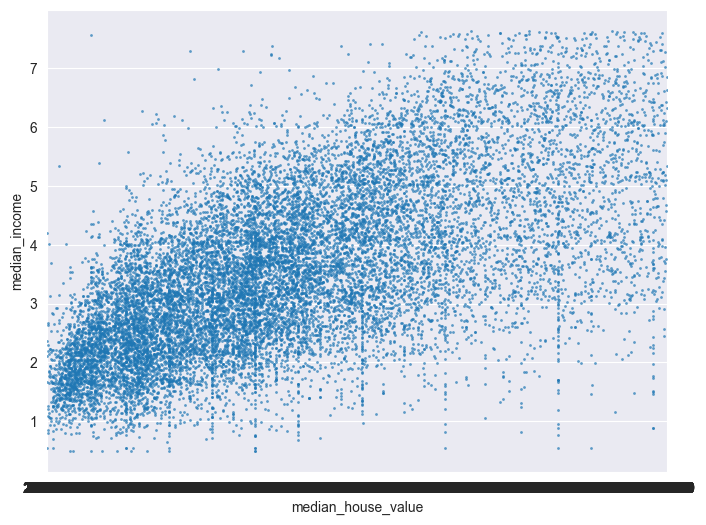

In [34]:
plt.figure(figsize=(8, 6))
sns.stripplot(data=houses_cleaned, x='median_house_value', y='median_income', jitter=True, size=2, alpha=0.7)

Splitting dataset into features and target variable.

In [35]:
X_raw = houses_cleaned.drop(columns='median_house_value')
y_raw = houses_cleaned['median_house_value']

Splitting dataset into 2 parts: training(85%), and test(15%).

In [36]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.15, random_state=4)


Data normalization: for ‘median_house_value’, ‘median_income’, ‘total_rooms’, ‘total_bedrooms’, ‘population’, ‘households’, and target value 'median_house_value' in train dataset we use logarithmic transformation because all values have right-skewed asymmetry, with a long tail to the right and a distribution that is not normal but closer to log-normal. Then, for all attributes, we perform robust scaling because of different scales and non-normal distribution.
We leave ‘latitude’ and ‘longitude’ untouched because they are geographical features and if we transform them, they will lose their informativeness.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

X_scaler = Pipeline([
    ('log_transform', ColumnTransformer([('log', FunctionTransformer(np.log1p, validate=False), [0, 1, 2, 3, 4, 5])], remainder='passthrough')),
    ('robust_scaling', ColumnTransformer([('robust', RobustScaler(), [0, 1, 2, 3, 4, 5])], remainder='passthrough',  verbose_feature_names_out=False))
])

y_scaler = Pipeline([('log', FunctionTransformer(np.log1p, validate=False)), ('robust', RobustScaler())])

X_train_trf = X_scaler.fit_transform(X_train_raw)

y_train_raw_2d = y_train_raw.to_frame()
y_train_trf = y_scaler.fit_transform(y_train_raw_2d)

X_train = pd.DataFrame(X_train_trf, columns=X_raw.columns)
y_train = pd.DataFrame(y_train_trf, columns=['median_house_value'])

Plotting histograms of normalized data.

array([[<Axes: title={'center': 'median_house_value'}>]], dtype=object)

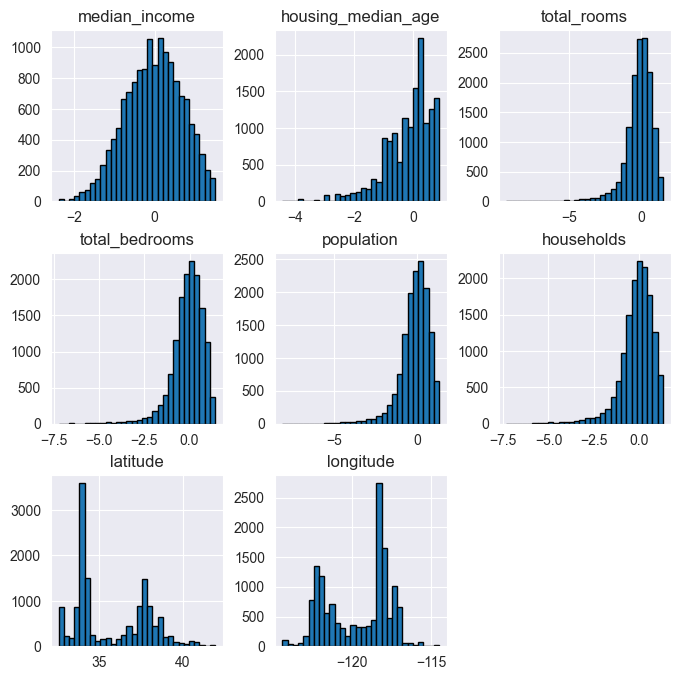

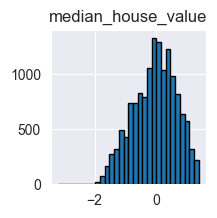

In [38]:
X_train.hist(figsize=(8, 8), bins=30, edgecolor='black')
y_train.hist(figsize=(2, 2), bins=30, edgecolor='black')

Making basic Multi-layer Perceptron Regressor model.

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model0 = Sequential([
    Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1)
])

model0.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training our model.

In [40]:
history0 = model0.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - loss: 28.9372 - mae: 3.2100 - val_loss: 1.4329 - val_mae: 0.9462
Epoch 2/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - loss: 1.1288 - mae: 0.8610 - val_loss: 0.9902 - val_mae: 0.8314
Epoch 3/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - loss: 0.9086 - mae: 0.7866 - val_loss: 0.8455 - val_mae: 0.7681
Epoch 4/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.7977 - mae: 0.7375 - val_loss: 0.7595 - val_mae: 0.7115
Epoch 5/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - loss: 0.7108 - mae: 0.6925 - val_loss: 0.6741 - val_mae: 0.6728


Defining a function to plot training and validation loss.

In [41]:
def plot_loss(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(6,3))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

We can see fast overfitting starting from second epoch.

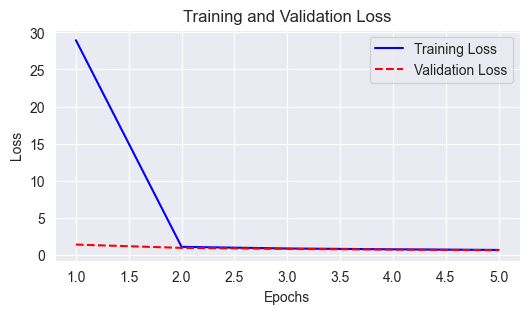

In [42]:
plot_loss(history0)

Defining a function to evaluate the model on the test set.

In [43]:
from sklearn.metrics import mean_squared_error

def evaluate_model(model, X, y):

    X_test_trf = X_scaler.transform(X)
    X_test = pd.DataFrame(X_test_trf, columns=X.columns)

    y_test_raw_2d  = y.to_frame()
    y_test_trf = y_scaler.transform(y_test_raw_2d)

    y_pred_scaled = model.predict(X_test)
    y_pred = np.expm1(y_scaler.named_steps['log'].inverse_transform(y_scaler.named_steps['robust'].inverse_transform(y_pred_scaled)))
    y_true = np.expm1(y_scaler.named_steps['log'].inverse_transform(y_scaler.named_steps['robust'].inverse_transform(y_test_trf)))

    mae = np.mean(np.abs(y_true - y_pred))
    print(f"Test Loss (MAE): {mae:.4f}")
    return y_true, y_pred


Mean Absolute Error is more than 90,000. We need to improve our model.

In [44]:
evaluate_model(model0, X_test_raw, y_test_raw)

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step
Test Loss (MAE): 90503.8427


(array([[210100.],
        [240300.],
        [247000.],
        ...,
        [179600.],
        [475000.],
        [ 95500.]], shape=(2539, 1)),
 array([[142641.3  ],
        [149305.19 ],
        [142051.73 ],
        ...,
        [ 97541.625],
        [411457.53 ],
        [188916.19 ]], shape=(2539, 1), dtype=float32))

In [45]:
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245 (984.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 164 (660.00 B)

Adding dropout 30% to our model for less overfitting.

In [46]:
model1 = Sequential([
    Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(1)
])

model1.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

history1 = model1.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5


C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 903.7542 - mae: 22.5947 - val_loss: 7.7341 - val_mae: 2.4927
Epoch 2/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 103.6376 - mae: 7.4522 - val_loss: 1.5016 - val_mae: 1.0399
Epoch 3/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - loss: 22.3307 - mae: 3.6366 - val_loss: 1.0645 - val_mae: 0.8614
Epoch 4/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 5.1330 - mae: 1.8524 - val_loss: 0.9434 - val_mae: 0.8041
Epoch 5/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 1.4985 - mae: 1.0206 - val_loss: 0.7584 - val_mae: 0.7126


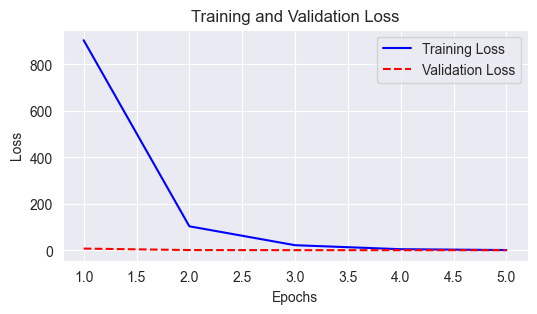

In [47]:
plot_loss(history1)

Results became better. Now MAE is 65,000.

In [53]:
evaluate_model(model1, X_raw, y_raw)

529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step
Test Loss (MAE): 93697.4062


(array([[352100.],
        [341300.],
        [342200.],
        ...,
        [ 92300.],
        [ 84700.],
        [ 89400.]], shape=(16923, 1)),
 array([[237480.9 ],
        [238264.69],
        [248062.28],
        ...,
        [247792.27],
        [247929.84],
        [237994.89]], shape=(16923, 1), dtype=float32))

Adding kernel regularizer.

In [55]:
from tensorflow.keras.regularizers import l2

model2 = Sequential([
    Dense(1, activation="relu", input_shape=((1,)), kernel_regularizer=l2(0.001)),
    Dropout(0.3)
])

model2.compile(optimizer=Adam(learning_rate=0.001), loss="mae", metrics=["mae"])

history2 = model2.fit(
    X_train['median_income'], y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

print(model2.weights)

Epoch 1/5


C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - loss: 0.7299 - mae: 0.7291 - val_loss: 0.6340 - val_mae: 0.6335
Epoch 2/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - loss: 0.5964 - mae: 0.5960 - val_loss: 0.5715 - val_mae: 0.5713
Epoch 3/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - loss: 0.5704 - mae: 0.5702 - val_loss: 0.5654 - val_mae: 0.5653
Epoch 4/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 0.5676 - mae: 0.5675 - val_loss: 0.5648 - val_mae: 0.5647
Epoch 5/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 0.5671 - mae: 0.5670 - val_loss: 0.5647 - val_mae: 0.5646
[<Variable path=sequential_4/dense_6/kernel, shape=(1, 1), dtype=float32, value=[[-0.3068666]]>, <Variable path=sequential_4/dense_6/bias, shape=(1,), dtype=float32, value=[-0.60411173]>]


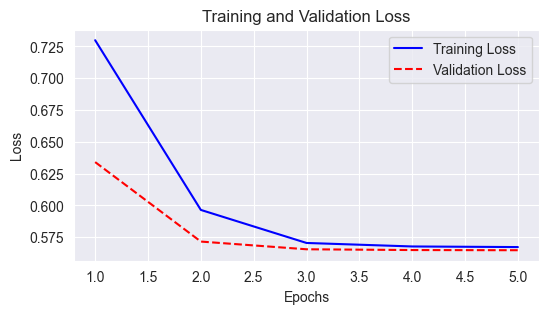

In [56]:
plot_loss(history2)

In [58]:

def evaluate_model1(model, X, y):

    X_test_trf = y_scaler.transform(X)
    X_test = pd.DataFrame(X_test_trf, columns=X.columns)

    y_test_raw_2d  = y.to_frame()
    y_test_trf = y_scaler.transform(y_test_raw_2d)

    y_pred_scaled = model.predict(X_test)
    y_pred = np.expm1(y_scaler.named_steps['log'].inverse_transform(y_scaler.named_steps['robust'].inverse_transform(y_pred_scaled)))
    y_true = np.expm1(y_scaler.named_steps['log'].inverse_transform(y_scaler.named_steps['robust'].inverse_transform(y_test_trf)))

    mae = np.mean(np.abs(y_true - y_pred))
    print(f"Test Loss (MAE): {mae:.4f}")
    return y_true, y_pred


evaluate_model1(model2, X_raw['median_income'], y_raw)

C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.